In [1]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

import captum 
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution

# for importing data
import torchvision
from torch.utils.data import DataLoader,Subset

import matplotlib.pyplot as plt
import sys
from os import path
from tqdm import tqdm

In [2]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [66]:
# import dataset 
# scores   = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_pca_scores.npy')
lfp      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_lfp.npy').astype(np.float32)
# power    = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_power.npy')
X   = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spikes.npy').astype(np.float32)

df       = pd.read_csv(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_info.csv')

bin_size = 0.004

# print(scores.shape)
print(lfp.shape)
# print(power.shape)
print(X.shape)

print(f'data length is {bin_size*lfp.shape[0]} sec')

(901125, 1)
(72248, 1)
(228004, 1)
torch.Size([125, 1, 748])
data length is 3604.5 sec


In [5]:
print(df.head())

  location   probe  firing_rate  dist_from_source
0      POL  probeB    12.605778       2436.860891
1      CA1  probeB     3.409879       1303.491849
2    VISpm  probeB     0.731049       1272.456679
3       DG  probeB     0.228691       1770.981931
4      POL  probeB     1.995846       2512.222323


In [6]:
# trim data and reshape for randomizing 
seqlength  = 125 # 500 * .002 = 1 sec resolution 

num_trials = int(lfp.shape[0]/seqlength)
X   = X[:num_trials*seqlength,:]
lfp = lfp[:num_trials*seqlength,:]
X_reshaped   = np.reshape(X, (num_trials, seqlength, X.shape[1])) # (trials, len, units)
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength)) # (trials, len)

In [7]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5767, 125, 748)
(1442, 125, 748)
(5767, 125)
(1442, 125)


In [8]:
# reshape back into time x neurons
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])
y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1],1)
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1],1)

In [9]:
# for initial training, use only the first 50 s of data 
# seglen = 3000 # in seconds 
# scores_train = spikes[:int(seglen/bin_size),:]
# lfp_train    = lfp[:int(seglen/bin_size)]
# power_train  = power[:int(seglen/bin_size),:]
# # lfp2    = lfp[int(10/bin_size):2*int(10/bin_size)]
# # scores2 = scores[int(10/bin_size):2*int(10/bin_size),:]
# print(scores_train.shape)
# print(lfp_train.shape)
# print(power_train.shape)

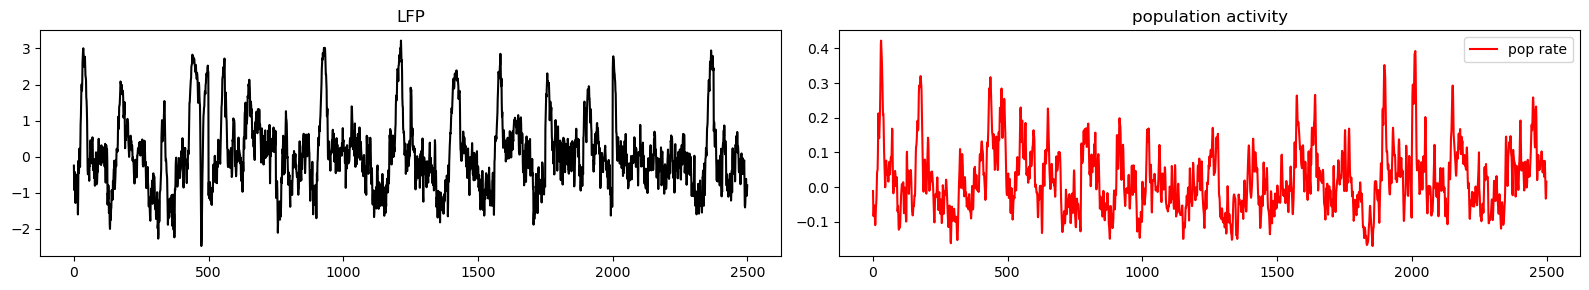

In [10]:
import matplotlib.gridspec as gridspec
fig, ax = plt.subplots(1,2,figsize=(16, 3))
# Create a GridSpec with 2 rows and 2 columns 
# gs = gridspec.GridSpec(2, 2, height_ratios=[1, 2])

ax[0].plot(y_train[:int(10/bin_size)],'k',label='LFP')
ax[0].set_title('LFP')

# ax2.plot(X_train[:int(10/bin_size),0],'r',label='N1')
# ax2.plot(X_train[:int(10/bin_size),1],'b',label='N2')
# ax2.plot(X_train[:int(10/bin_size),2],'m',label='N3')
# ax2.plot(X_train[:int(10/bin_size),3],'g',label='N4')
pop = np.mean(X_train,1)
ax[1].plot(pop[:int(10/bin_size)],'r',label='pop rate')
ax[1].set_title('population activity')
ax[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# set layer parameters
input_size  = X_train.shape[1]  # number of features to extract (number of data channels) 5 for scores
hidden_size = 10  # number of units in the hidden state
num_layers  = 1  # number of vertical stacks of hidden layers (note: only the final layer gives an output)
batchsize   = 1
print(f'using a sequence length of {bin_size*seqlength*1000} ms')

using a sequence length of 500.0 ms


In [67]:
# convert to tensors 
X_trainT = torch.tensor( X_train ).float()
y_trainT = torch.tensor( y_train ).float()
X_testT = torch.tensor( X_test ).float()
y_testT = torch.tensor( y_test ).float()
# powerT  = torch.tensor( power_train ).float()

## create the model

In [13]:
class LSTMnet(nn.Module):
  def __init__(self,input_size,num_hidden,num_layers, print=False):
    super().__init__()

    # store parameters
    self.print = print
    self.input_size = input_size
    self.num_hidden = num_hidden
    self.num_layers = num_layers

    # LSTM Layer 
    self.lstm = nn.LSTM(input_size,num_hidden,num_layers,dropout=.5)

    # linear layer for output
    self.out = nn.Linear(num_hidden,1)

  def forward(self,x):
    # h0 = torch.zeros(self.num_layers, x.size(0), self.num_hidden).to(x.device) 
    # c0 = torch.zeros(self.num_layers, x.size(0), self.num_hidden).to(x.device)
                     
    print(f'Input: {list(x.shape)}') if self.print else None

    # run through the RNN layer
    y,hidden = self.lstm(x)
    print(f'RNN-out: {list(y.shape)}') if self.print else None
    print(f'RNN-hidden: {list(hidden[0].shape)}') if self.print else None
    print(f'RNN-cell: {list(hidden[1].shape)}') if self.print else None

    # pass the RNN output through the linear output layer
    o = self.out(y)
    print(f'Output: {list(o.shape)}') if self.print else None

    return o #,hidden

In [14]:
# create an LSTM instance
net = LSTMnet(input_size,hidden_size,num_layers, print = True)

# test the model with some data
somedata = X_trainT[:seqlength,:].view(seqlength,1,input_size)
# somedata = lfpT[:seqlength].view(seqlength,1,input_size)

y  = net(somedata)
# print(torch.squeeze(y))

lossfun = nn.MSELoss()
lossfun(torch.squeeze(y), torch.squeeze(y_trainT[:seqlength]))

Input: [125, 1, 748]
RNN-out: [125, 1, 10]
RNN-hidden: [1, 1, 10]
RNN-cell: [1, 1, 10]
Output: [125, 1, 1]


C:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


tensor(1.5173, grad_fn=<MseLossBackward0>)

## a function to train the model 

In [15]:
def train(model_inp, numepochs = 50):
    
    N = y_train.shape[0]
    # net = LSTMnet(input_size,hidden_size,num_layers)
    model_inp.to(device)
        
    optimizer = torch.optim.Adam(model_inp.parameters(),lr=.001, weight_decay=0.001)
    
    # initialize losses
    losses = np.zeros(numepochs)
    
    # loop over epochs
    for epochi in range(numepochs):
    
      # loop over data segments
      seglosses = []
      hidden_state = torch.zeros(num_layers,batchsize,hidden_size) # reset the hidden state on each epoch
    
      for timei in range(0, N - seqlength, seqlength):
    
        # grab a snippet of data
        X = X_trainT[timei:timei+seqlength,:].view(seqlength,1,input_size)
        # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
        y = y_trainT[timei:timei+seqlength].view(seqlength,1)
        # y = powerT[timei:timei+seqlength,4].view(seqlength,1)
          
        # push data to GPU
        X = X.to(device)
        y = y.to(device)  
        
        # forward pass and loss
        yHat = model_inp(X)
        # finalValue = yHat[-1]
        # loss = lossfun(finalValue,y) # compare final value of output
        loss = lossfun(torch.squeeze(y), torch.squeeze(yHat))
        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # loss from this segment
        seglosses.append(loss.item())
    
      # average losses from this epoch
      losses[epochi] = np.mean(seglosses)
      
      msg = f'Finished epoch {epochi+1}/{numepochs}'
      sys.stdout.write('\r' + msg)

    return losses

In [22]:
def train_load_save_model(model_obj, model_path):
    if path.isfile(model_path):
        # load model
        print('Loading pre-trained model from: {}'.format(model_path))
        model_obj.load_state_dict(torch.load(model_path, weights_only=True))
    else:    
        # train model
        losses = train(model_obj)
        print('Finished training the model. Saving the model to the path: {}'.format(model_path))
        torch.save(model_obj.state_dict(), model_path)
        return losses

In [26]:
model = LSTMnet(input_size,hidden_size,num_layers)

SAVED_MODEL_PATH = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_trained_lstm.pt'
train_load_save_model(model, SAVED_MODEL_PATH)
model = model.to(device)

Loading pre-trained model from: Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_trained_lstm.pt


C:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


In [37]:
# fig,ax = plt.subplots(1,1,figsize=(5,3))

# ax.plot(losses,'s-')
# ax.set_xlabel('Epochs')
# ax.set_ylabel('Loss')
# ax.set_title('Model loss')


## test the network

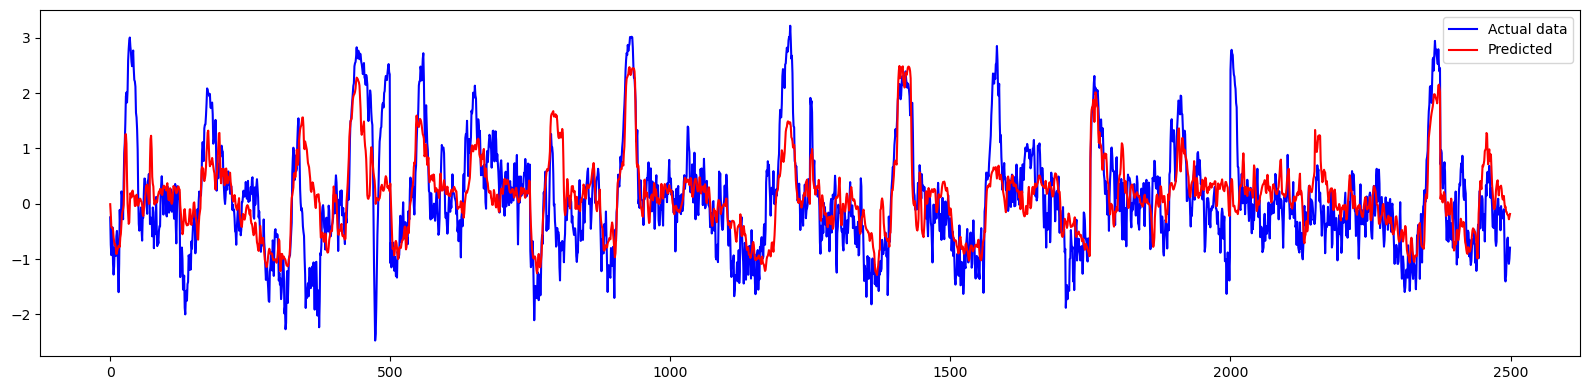

In [27]:
# initialize hidden state
# h = np.zeros((N,hidden_size))
N = y_train.shape[0]

# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan
# yHat = torch.from_numpy(yHat)
# yHat = yHat.to(device)

# loop over time segments
for timei in range(0, N - seqlength, seqlength):

  # grab a snippet of data
  X = X_trainT[timei:timei+seqlength,:].view(seqlength,1,input_size)
  X = X.to(device)
  # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
  
  # forward pass and loss
  yy = model(X)
  yHat[timei:timei+seqlength] = np.squeeze(yy.cpu().detach().numpy()) # [timei:timei+seqlength]
  # h[timei+seqlength,:] = hh[0].detach()

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_train[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(yHat[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()


## Test on new data

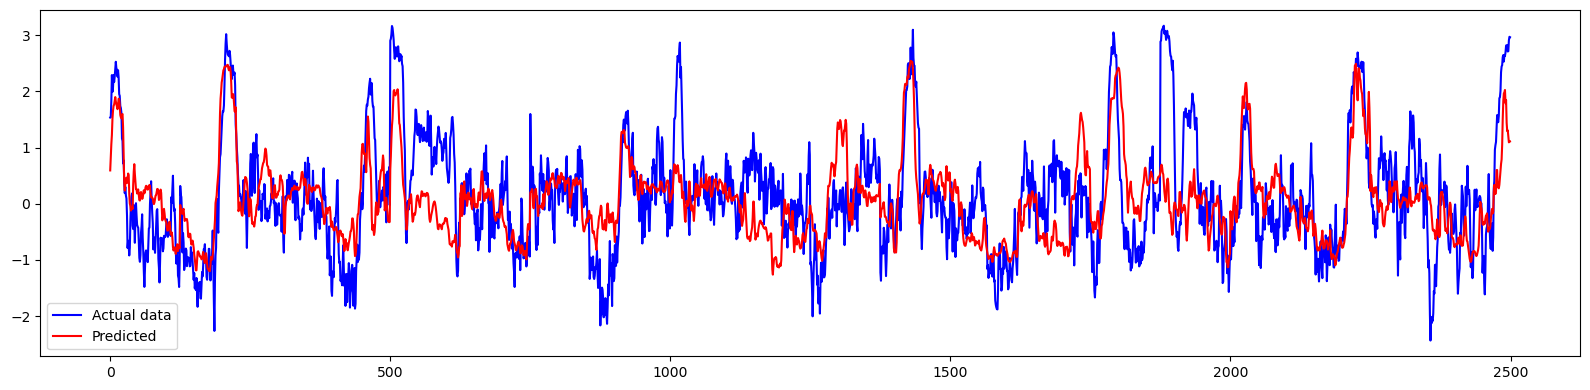

In [92]:
## test the network with unseen data
# note: no learning here!
N = y_test.shape[0]
model.eval()
# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan
# yHat = torch.from_numpy(yHat)
# yHat = yHat.to(device)

# loop over time segments
for timei in range(0, N - np.mod(N,seqlength), seqlength):

  # grab a snippet of data
  X = X_testT[timei:timei+seqlength,:].view(seqlength,1,input_size)
  X = X.to(device)
  # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
  
  # forward pass and loss
  yy = model(X)
  yHat[timei:timei+seqlength] = np.squeeze(yy.cpu().detach().numpy()) # [timei:timei+seqlength]
  # h[timei+seqlength,:] = hh[0].detach()

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_test[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(yHat[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [95]:
# print mse for test data 
print(f'MSE test data: {lossfun(torch.squeeze(y_testT), torch.squeeze(torch.tensor(yHat)))}')

MSE test data: 0.6872598586114376


## test on spontaneous data

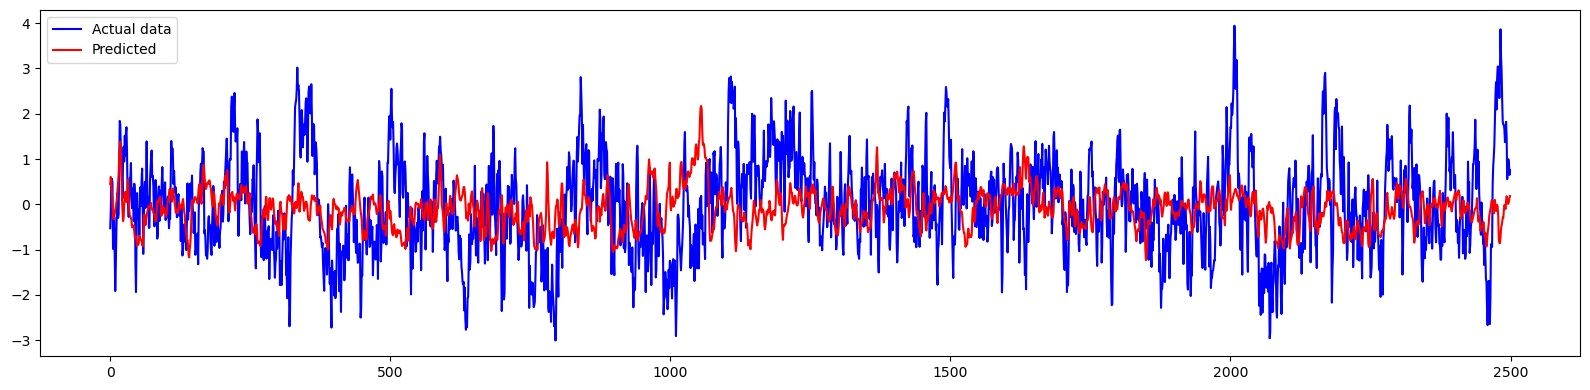

In [96]:
X_spont    = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spikes_spont.npy').astype(np.float32)
spont      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spont_lfp.npy').astype(np.float32)
X_spontT   = torch.tensor( X_spont ).float()
spont_lfpT = torch.tensor( spont ).float()

# gabor      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_gabor_lfp.npy').astype(np.float32)
# gaborT = torch.tensor( gabor ).float()

N = spont_lfpT.shape[0]
model.eval()
# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan
# yHat = torch.from_numpy(yHat)
# yHat = yHat.to(device)

# loop over time segments
for timei in range(0, N - np.mod(N,seqlength), seqlength):

  # grab a snippet of data
  X = X_spontT[timei:timei+seqlength,:].view(seqlength,1,input_size)
  X = X.to(device)
  # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
  
  # forward pass and loss
  yy = model(X)
  yHat[timei:timei+seqlength] = np.squeeze(yy.cpu().detach().numpy()) # [timei:timei+seqlength]
  # h[timei+seqlength,:] = hh[0].detach()

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(spont[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(yHat[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [100]:
# print mse for test data 
print(f'MSE spontaneous data: {lossfun(torch.squeeze(spont_lfpT[:N - np.mod(N,seqlength)]), torch.squeeze(torch.tensor(yHat[:N - np.mod(N,seqlength)])))}')

MSE spontaneous data: 1.192360565728224


## test on gabor stimulations data

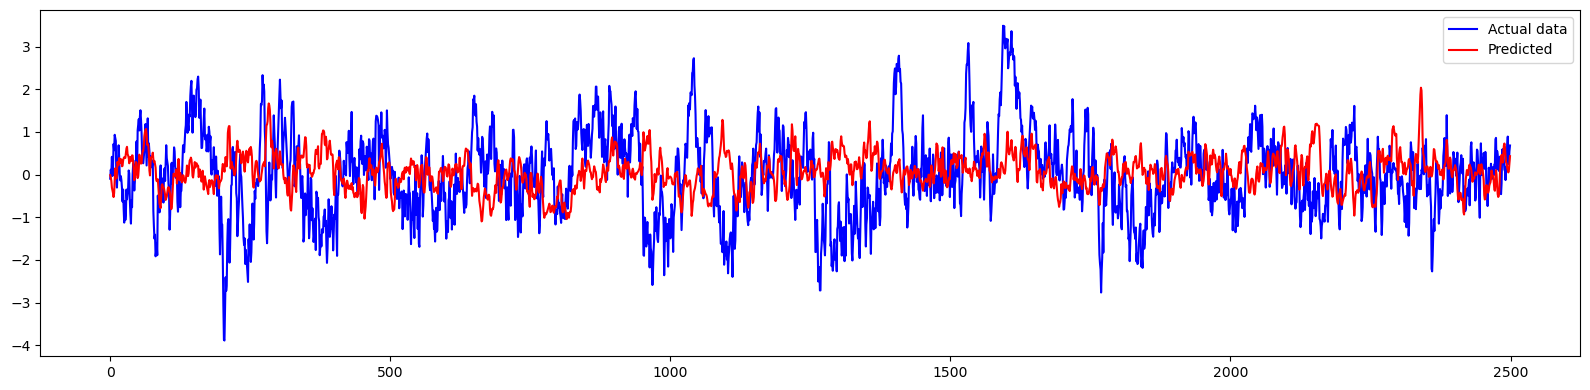

In [71]:
X_gabor    = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spikes_gabor.npy').astype(np.float32)
gabor      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_gabor_lfp.npy').astype(np.float32)
X_gaborT   = torch.tensor( X_gabor ).float()
gabor_lfpT = torch.tensor( gabor ).float()

N = gabor_lfpT.shape[0]
model.eval()
# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan
# yHat = torch.from_numpy(yHat)
# yHat = yHat.to(device)

# loop over time segments
for timei in range(0, N - seqlength, seqlength):

  # grab a snippet of data
  X = X_gaborT[timei:timei+seqlength,:].view(seqlength,1,input_size)
  X = X.to(device)
  # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
  
  # forward pass and loss
  yy = model(X)
  yHat[timei:timei+seqlength] = np.squeeze(yy.cpu().detach().numpy()) # [timei:timei+seqlength]
  # h[timei+seqlength,:] = hh[0].detach()

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(gabor[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(yHat[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

## attribution analysis using captum

In [29]:
model.train()
X_testT = X_testT.to(device)

# Initialize the attribution algorithm with the model
integrated_gradients = IntegratedGradients(model)
attributions = []
for i in tqdm(range(0,X_testT.shape[0],300)):
  attributions.append(integrated_gradients.attribute(X_testT[i:i+300,:].contiguous(),  target=0,  n_steps=200))

100%|████████████████████████████████████████████████████████████████████████████████| 601/601 [18:31<00:00,  1.85s/it]


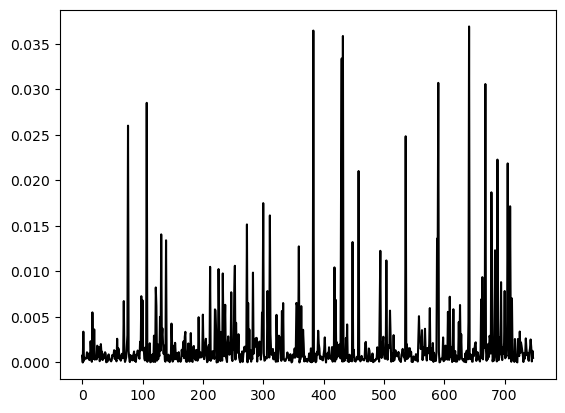

In [44]:
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()
mean_attr_over_time = np.mean(attributions,0)
df['attribution'] = mean_attr_over_time

plt.plot(np.arange(0,X_testT.shape[1],1), np.abs(mean_attr_over_time) , 'k')
plt.show()

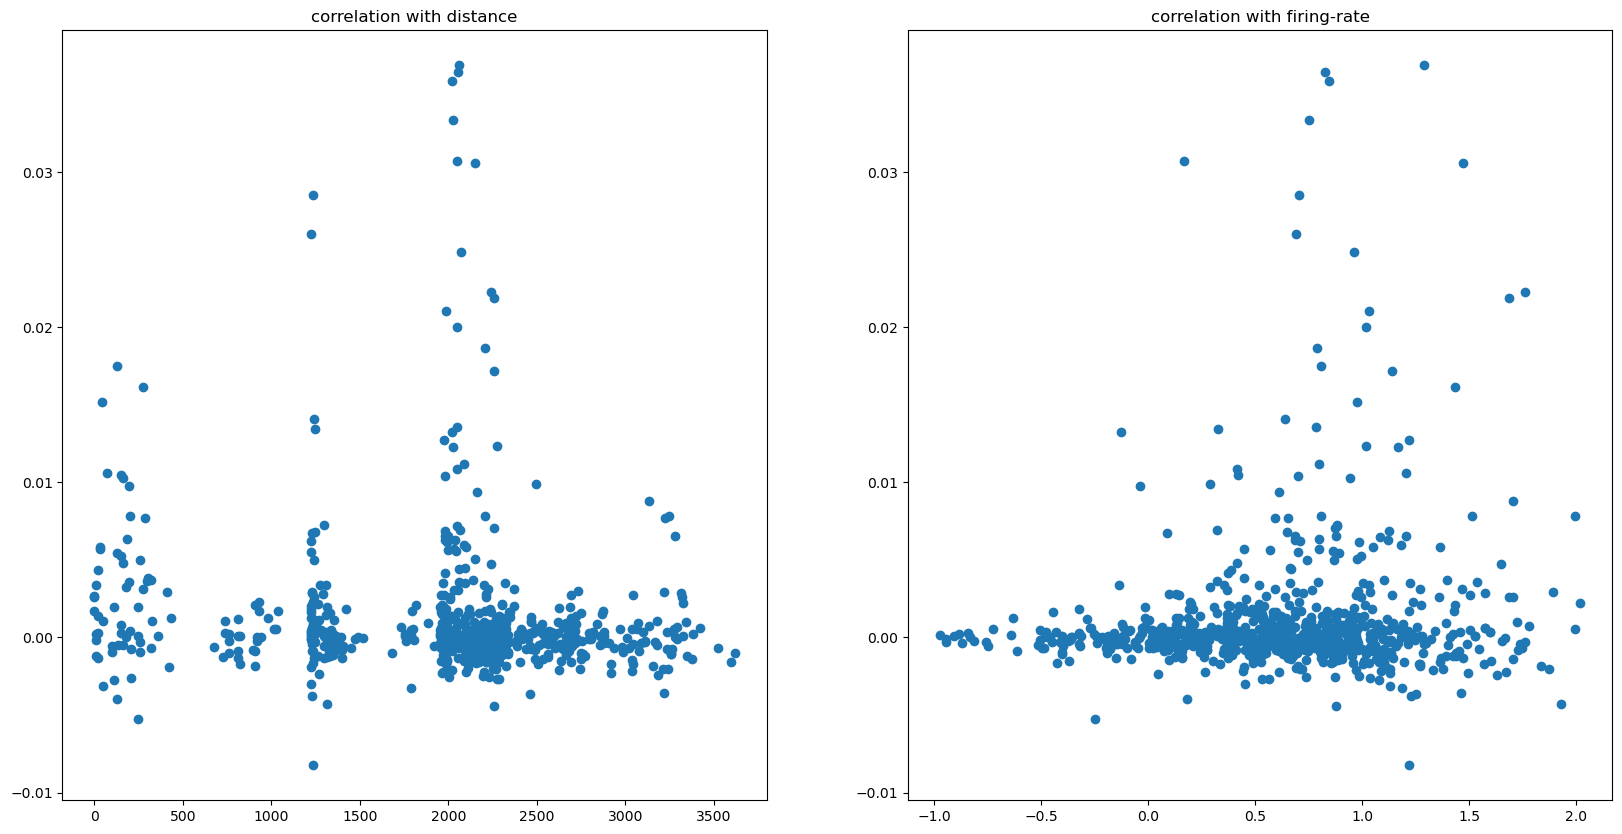

In [40]:
fig, ax = plt.subplots(1,2, figsize=(20,10))

ax[0].scatter(df.dist_from_source, mean_attr_over_time)
ax[0].set_title('correlation with distance')

ax[1].scatter(np.log10(df.firing_rate), mean_attr_over_time)
ax[1].set_title('correlation with firing-rate')
plt.show()

In [45]:
df.head()

,location,probe,firing_rate,dist_from_source,attribution
0,POL,probeB,12.605778,2436.860891,-7.440950e-04
1,CA1,probeB,3.409879,1303.491849,2.420166e-07
2,VISpm,probeB,0.731049,1272.456679,3.385959e-03
3,DG,probeB,0.228691,1770.981931,1.863473e-04
4,POL,probeB,1.995846,2512.222323,5.265902e-04


In [47]:
df[['location', 'attribution', 'firing_rate', 'dist_from_source']].groupby('location').mean().sort_values('attribution',ascending=False)

,attribution,firing_rate,dist_from_source
location,,,
VISal,0.004804,6.426208,2081.784036
VISl,0.003292,4.774797,1991.944407
MGm,0.003088,19.001668,2966.190374
VISrl,0.003002,10.296141,2237.059371
VISp,0.002823,6.818366,164.659059
VISpm,0.002113,4.947556,1242.218513
PP,0.001923,68.461265,3331.802449
PIL,0.001105,42.893935,3112.033759
MGv,0.000406,10.434417,2825.663030


location                  VISal
probe                    probeE
firing_rate           19.355614
dist_from_source    2063.456566
attribution            0.036904
Name: 641, dtype: object


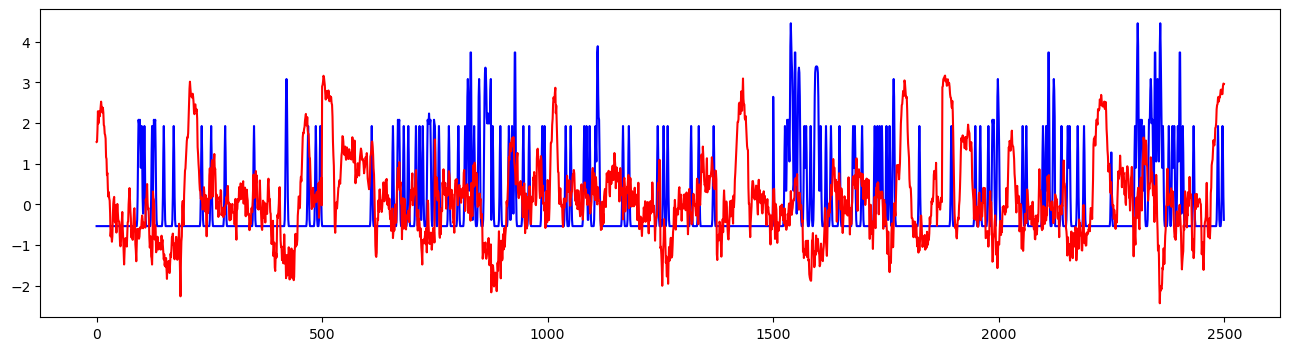

In [64]:
# find the neuron with the highest attribution 
sidx = np.argsort(mean_attr_over_time)[::-1]
print(df.iloc[sidx[0]])
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(X_test[:int(10/bin_size),sidx[0]],'b',label='best predictor neuron')
ax.plot(y_test[:int(10/bin_size)],'r',label='LFP')
# ax.legend()